# Deutsch-Jozsa Algorithm — Demo

Walks through `algorithms.deutsch_jozsa` end to end: build a constant and a
balanced oracle, visualize the circuit and its measurement histogram, and
run `is_constant()` on each.

See [../math.md](../math.md) for the promise-problem theory and
[../paper.md](../paper.md) for the circuit derivation this notebook
exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from algorithms.deutsch_jozsa import visualization
from algorithms.deutsch_jozsa.circuit import build_oracle_query_circuit
from algorithms.deutsch_jozsa.execution import AerExecutor
from algorithms.deutsch_jozsa.implementation import is_constant
from algorithms.deutsch_jozsa.oracles import BalancedOracle, ConstantOracle, ParityOracle

n_qubits = 3
executor = AerExecutor()

## A constant oracle

`f(x) = 1` for all `x`. The circuit should measure all-zeros with
certainty.

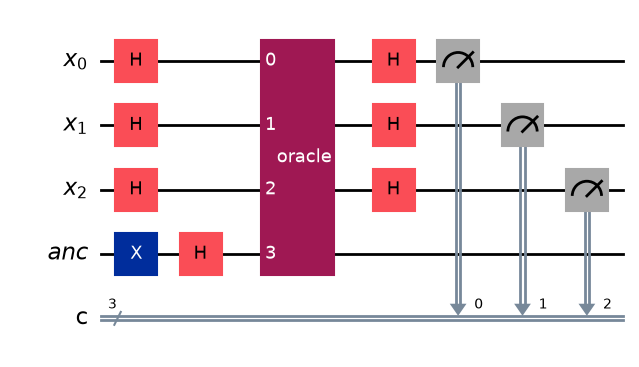

In [3]:
constant_oracle = ConstantOracle(n_qubits, value=1)
constant_circuit = build_oracle_query_circuit(n_qubits, constant_oracle)
visualization.circuit_figure(constant_circuit)

{'000': 100}


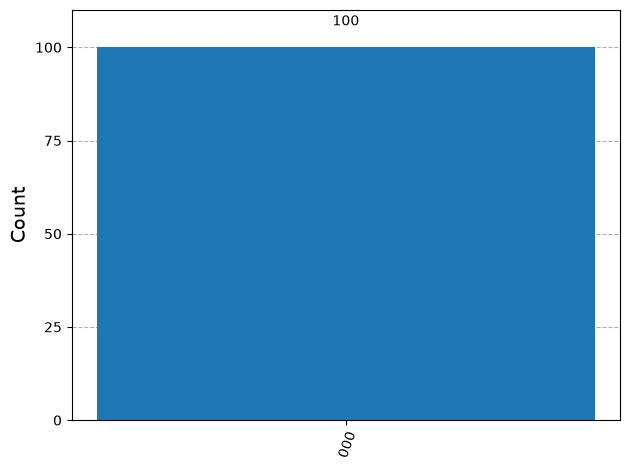

In [4]:
counts = executor.run(constant_circuit, shots=100)
print(counts)
visualization.plot_measurement_histogram(counts)

## A balanced oracle

`ParityOracle` marks a linear (always-balanced) function. The circuit
should measure a nonzero bitstring with certainty — never all-zeros.

{'101': 100}


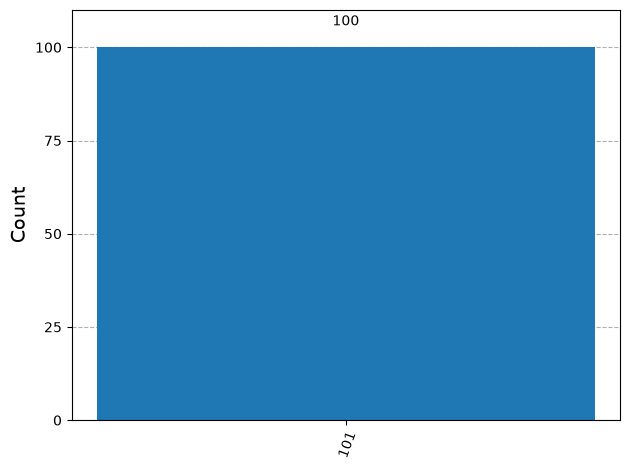

In [5]:
balanced_oracle = ParityOracle(n_qubits, {0, 2})
balanced_circuit = build_oracle_query_circuit(n_qubits, balanced_oracle)
counts = executor.run(balanced_circuit, shots=100)
print(counts)
visualization.plot_measurement_histogram(counts)

## `is_constant`

Wraps circuit construction, execution, and interpretation into one call —
a single shot suffices (see math.md).

In [6]:
print("constant oracle:", is_constant(n_qubits, constant_oracle))
print("balanced (parity) oracle:", is_constant(n_qubits, balanced_oracle))

# BalancedOracle: general but exponential (see paper.md) - fine at this small n_qubits
marked = {format(i, "03b") for i in range(4)}
explicit_oracle = BalancedOracle(n_qubits, marked)
print("balanced (explicit marked-set) oracle:", is_constant(n_qubits, explicit_oracle))

constant oracle: True


balanced (parity) oracle: False
balanced (explicit marked-set) oracle: False
